# **Нелинейные модели против южной погоды**

## Описание исследования

Компания BikeSouth развивает систему городского велопроката на юге России. Для стабильной работы сервиса важно заранее понимать, сколько велосипедов потребуется пользователям в разные часы суток. Точный прогноз спроса позволяет правильно распределять велосипеды между станциями, избегать их нехватки в часы пик и снижать простои.

Ранее компания использовала простую модель линейной регрессии, однако её точность оказалась недостаточной. Модель плохо учитывает сочетание погодных факторов. Например, одинаковая температура может по-разному влиять на спрос в зависимости от влажности, солнечной активности или осадков.

В рамках данного проекта проводится анализ данных о погодных условиях и аренде велосипедов, а также разработка более точной модели машинного обучения, способной учитывать нелинейные зависимости между признаками и прогнозировать почасовой спрос.

⸻

## Цель исследования

Разработать модель машинного обучения, которая сможет точно прогнозировать количество велосипедов, арендуемых в каждый час, на основе погодных и календарных факторов, чтобы помочь компании BikeSouth улучшить планирование логистики и распределение велосипедов.

⸻

## Задачи исследования

Для достижения поставленной цели необходимо выполнить следующие задачи:
	•	изучить и проанализировать предоставленные данные о погоде и аренде велосипедов  
	•	провести первичный анализ данных (EDA) и выявить факторы, влияющие на спрос  
	•	подготовить данные для моделирования и построить базовую модель линейной регрессии  
	•	разработать и обучить две нелинейные модели регрессии: kNN и дерево решений  
	•	провести подбор гиперпараметров моделей с использованием библиотеки Optuna  
	•	оценить качество моделей с помощью кросс-валидации по метрикам RMSE, MAE и R²  
	•	выбрать лучшую модель и проверить её качество на тестовой выборке  
	•	проанализировать важность признаков и определить факторы, сильнее всего влияющие на спрос  
	•	сформулировать рекомендации для компании BikeSouth по использованию модели и возможному улучшению прогнозов.

⸻

## Исходные данные

Для выполнения проекта компания предоставила два датасета.

ds_s14_train_data.csv — используется для обучения моделей и подбора гиперпараметров.

ds_s14_test_data.csv — используется только для финальной оценки качества модели.

Тестовая выборка не используется на этапах обучения и настройки моделей, чтобы обеспечить честную и независимую оценку качества.

Датасеты содержат почасовые данные о количестве арендованных велосипедов и погодных условиях, которые могут влиять на спрос.

Основные признаки в данных:
	•	Temperature — температура воздуха (°C)  
	•	Humidity — относительная влажность воздуха (%)  
	•	Wind speed — скорость ветра (м/с)  
	•	Visibility — видимость (в десятках метров)  
	•	Dew Point Temperature — точка росы (°C)  
	•	Solar Radiation — солнечная радиация (MJ/m²)  
	•	Rainfall — количество осадков (мм)  
	•	Snowfall — количество снега (см)  
	•	Seasons — время года (Winter, Spring, Summer, Autumn)  
	•	Holiday — признак выходного или праздничного дня  
	•	Time_Period_* — временной период суток (ночь, утро, день, вечер, поздний вечер).  
  
Целевая переменная:

Rented Bike Count — количество велосипедов, арендованных за конкретный час.

⸻

## Постановка задачи машинного обучения

Задача проекта формулируется как задача регрессии с обучением с учителем.

Модель получает на вход набор признаков, описывающих погодные условия, сезон и время суток, и должна предсказать число велосипедов, которое будет арендовано в данный час.

Тип задачи: регрессия.

Тип обучения: обучение с учителем.

Целевая переменная: Rented Bike Count.

Основной метрикой качества модели выбрана RMSE (Root Mean Squared Error), так как она отражает среднюю величину ошибки прогноза и чувствительна к крупным ошибкам, что важно для задач прогнозирования спроса.

Дополнительно используются метрики:  
	•	MAE (Mean Absolute Error) — для оценки средней абсолютной ошибки    
	•	R² (коэффициент детерминации) — для оценки доли объяснённой вариации спроса.  

Для оценки качества моделей используется кросс-валидация с 5 фолдами, что позволяет получить устойчивую оценку и корректно сравнить различные алгоритмы.

В рамках проекта рассматриваются следующие модели:
	•	baseline-модель — линейная регрессия  
	•	k-ближайших соседей (kNN)  
	•	дерево решений.  

Лучшая модель выбирается по результатам кросс-валидации и затем один раз проверяется на тестовой выборке, чтобы оценить её способность прогнозировать спрос на новых данных.


## **Часть 1. Работа с базовой моделью**

### Импорт библиотек и загрузка данных

In [1]:
import sys

!{sys.executable} -m pip uninstall -y -q numpy scipy pandas scikit-learn joblib matplotlib seaborn phik statsmodels
!{sys.executable} -m pip install -U -q --no-cache-dir "numpy==2.0.2" "scipy==1.13.1" "scikit-learn==1.6.1" "joblib==1.4.2"
!{sys.executable} -m pip install -U -q --no-cache-dir "pandas==2.2.2" "matplotlib==3.8.4" "seaborn==0.13.2" "phik==0.12.4" "statsmodels==0.14.2"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyod 0.9.5 requires matplotlib, which is not installed.
pyod 0.9.5 requires statsmodels, which is not installed.
catboost 1.0.3 requires matplotlib, which is not installed.
catboost 1.0.3 requires pandas>=0.24.0, which is not installed.
numba 0.56.0 requires numpy<1.23,>=1.18, but you have numpy 2.0.2 which is incompatible.


In [2]:
pip install optuna -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pickle 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import phik as ph
from phik import phik_matrix

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance

import math

import optuna



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/conda/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/conda/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/conda/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.9/site-packages/traitlets/config/application.py", line 845, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.9/site-packages/ipykernel/kerne

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/conda/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/conda/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/conda/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.9/site-packages/traitlets/config/application.py", line 845, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.9/site-packages/ipykernel/kerne

AttributeError: _ARRAY_API not found

In [4]:
RANDOM_STATE = 42

In [5]:
df_train = pd.read_csv('/datasets/ds_s14_train_data.csv')
df_test = pd.read_csv('/datasets/ds_s14_test_data.csv')

display(df_train.head())
df_test.head()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005


In [6]:
df_train['Rented_Bike_Count'] = df_train['Rented Bike Count']
df_train = df_train.drop(columns=['Rented Bike Count'])

df_test['Rented_Bike_Count'] = df_test['Rented Bike Count']
df_test = df_test.drop(columns=['Rented Bike Count'])

df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Per

In [7]:
X = df_train.drop(columns=['Rented_Bike_Count'])
y = df_train['Rented_Bike_Count']

In [8]:
import joblib

loaded_pipe = joblib.load('/datasets/baseline_linear_regression_pipeline.pkl')
loaded_pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)']),
                                                 ('str_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day']),
                                                 ('ohe_pass', 'passthrough',
                                                  ['Time_Period_Evening',
                                                   'Time_Period_Late Evening',
                                                   'Time_Period_Morning',
                                                   'Time_Period_Night'])])),
                ('regressor', LinearRegression())])

In [9]:
y_LM_pred = loaded_pipe.predict(X)

round(mean_squared_error(y, y_LM_pred), 3), round(mean_absolute_error(y, y_LM_pred), 3), round(r2_score(y, y_LM_pred), 3)

(170177.993, 309.078, 0.593)

получили качество бейзлайна 

## **Часть 2. Улучшение модели — kNN и дерево решений**

### Анализ целевой переменной 



In [10]:
sns.set_theme(style='darkgrid')

def plot_outliers(df, col, bins=50):
    """
    Строит boxplot и гистограмму для численного признака.
    """

    f, (ax_box, ax_hist) = plt.subplots(
        2,
        sharex=True,
        gridspec_kw={'height_ratios': (0.15, 0.85)},
        figsize=(10, 6))

    sns.boxplot(
        x=df[col],
        orient='h',
        ax=ax_box)

    sns.histplot(
        data=df,
        x=col,
        bins=bins,
        ax=ax_hist)

    ax_box.set(xlabel='')
    ax_hist.set_xlabel(col)
    ax_hist.set_title(f'Распределение и boxplot признака {col}')

    plt.tight_layout()
    plt.show()

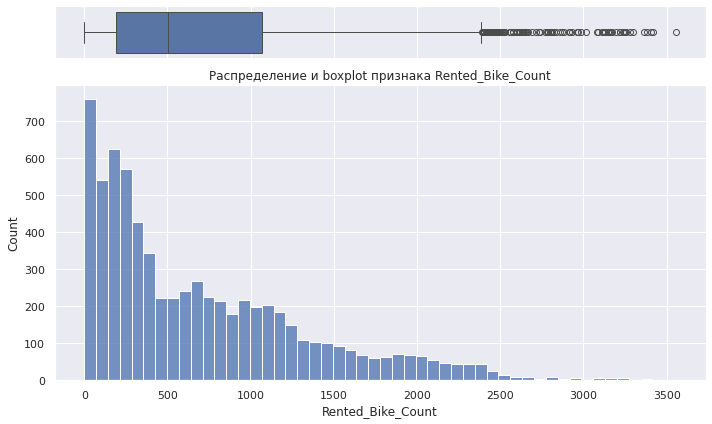

In [11]:
plot_outliers(df_train, 'Rented_Bike_Count')

распределение смещенное: большинство значений и 0 до 1000, длинный правый хвост 

In [12]:
def plot_target_vs_categorical(df, target, categorical_feature):
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot
    sns.boxplot(x=df[categorical_feature], y=df[target], ax=axes[0])
    axes[0].set_title(f'{target} by {categorical_feature}')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Средние значения
    means = df.groupby(categorical_feature)[target].mean().reset_index()
    sns.barplot(x=categorical_feature, y=target, data=means, ax=axes[1])
    axes[1].set_title(f'Mean {target} by {categorical_feature}')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

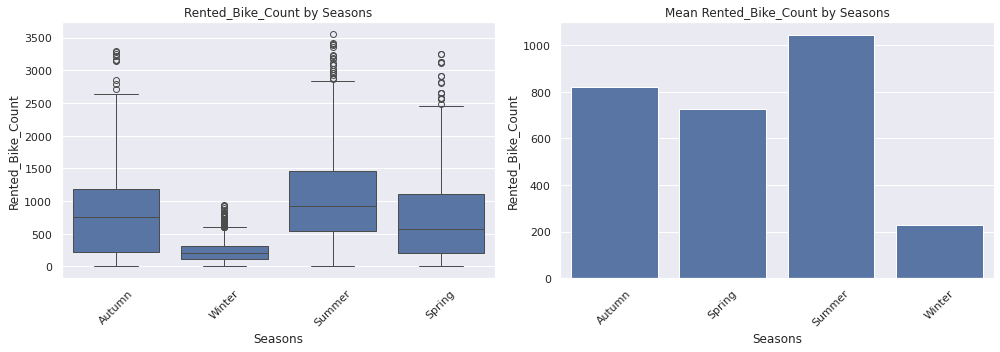

In [13]:
plot_target_vs_categorical(df_train, 'Rented_Bike_Count', 'Seasons')

явное сезонное колебание: зимой спрос заметно ниже, чем в остальные времена года. 

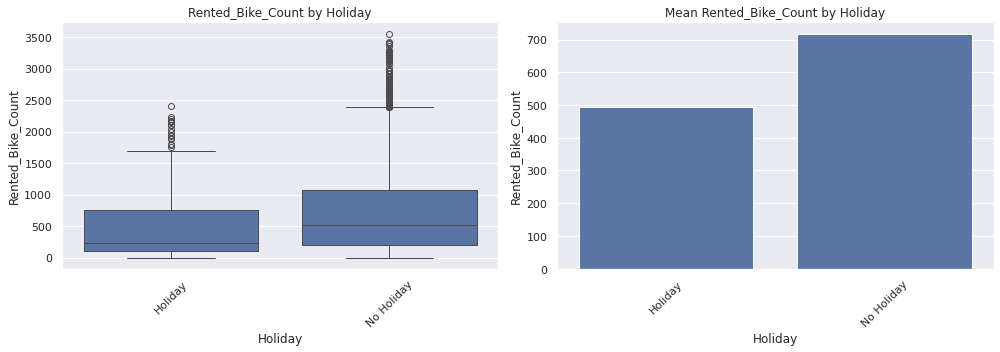

In [14]:
plot_target_vs_categorical(df_train, 'Rented_Bike_Count', 'Holiday')

в праздничные дни спрос в среднем ниже. 

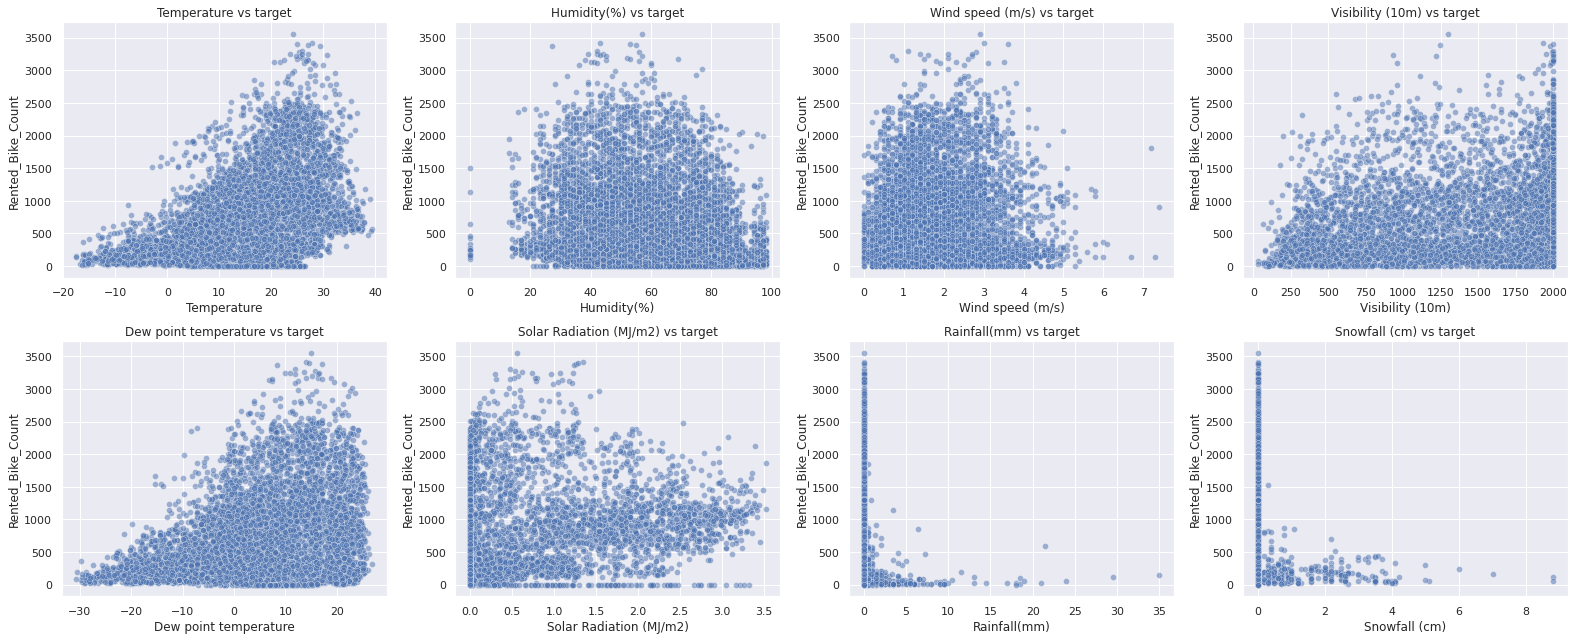

In [15]:
numeric_columns = [
    'Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
    'Dew point temperature', 'Solar Radiation (MJ/m2)',
    'Rainfall(mm)', 'Snowfall (cm)'
]

n = len(numeric_columns)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows))
axes = axes.ravel()

for i, col in enumerate(numeric_columns):
    sns.scatterplot(x=df_train[col], y=y, ax=axes[i], alpha=0.5)
    axes[i].set_title(f'{col} vs target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Rented_Bike_Count')

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Анализ пропущенных значений 

In [16]:
(df_train.isna().sum()/len(df_train)).sort_values(ascending=False)

Snowfall (cm)               0.037529
Rainfall(mm)                0.037386
Visibility (10m)            0.036958
Humidity(%)                 0.035674
Solar Radiation (MJ/m2)     0.029966
Wind speed (m/s)            0.029966
Temperature                 0.000000
Dew point temperature       0.000000
Seasons                     0.000000
Holiday                     0.000000
Functioning Day             0.000000
Time_Period_Evening         0.000000
Time_Period_Late Evening    0.000000
Time_Period_Morning         0.000000
Time_Period_Night           0.000000
Rented_Bike_Count           0.000000
dtype: float64

заполним пропуски медианой с флагом. 

### Категоральные признаки

In [17]:
df_train['Holiday'].unique()

array(['Holiday', 'No Holiday'], dtype=object)

In [18]:
df_train['Functioning Day'].unique()

array(['Yes', 'No'], dtype=object)

используем OHE для кодирования (признаки бинарные) 

In [19]:
df_train['Seasons'].unique()

array(['Autumn', 'Winter', 'Summer', 'Spring'], dtype=object)

тут тоже исползуем OHE (мало уникальных значений). 

### Выводы по исследовательскому анализу данных

В ходе первичного анализа данных были изучены распределение целевой переменной, влияние категориальных признаков, взаимосвязи числовых признаков со спросом, а также наличие пропущенных значений.

Распределение целевой переменной Rented_Bike_Count является асимметричным и имеет выраженный правый хвост.
Большинство наблюдений лежит в диапазоне примерно от 0 до 1000 аренд в час, однако присутствуют значения значительно выше — до 3500 аренд. Это указывает на наличие периодов с очень высоким спросом (например, благоприятная погода и часы пик). Такие значения отображаются как выбросы на boxplot, однако они могут отражать реальные пиковые нагрузки, поэтому удалять их нецелесообразно.

Анализ категориального признака Seasons показал выраженную сезонность спроса.
Наибольшее среднее количество аренд наблюдается летом, немного ниже — осенью и весной, а зимой спрос значительно ниже. Это логично с точки зрения поведения пользователей: в холодное время года велосипеды используются реже.

Признак Holiday также влияет на спрос.
Среднее количество аренд в праздничные и выходные дни ниже, чем в обычные рабочие дни. Вероятно, в будние дни велосипеды чаще используются как средство передвижения (например, для поездок на работу), тогда как в выходные структура передвижений меняется.

Анализ числовых признаков показал следующие тенденции:

Температура и точка росы демонстрируют положительную связь со спросом: при более тёплой погоде количество аренд увеличивается.

Влажность имеет обратную зависимость со спросом — при высокой влажности количество поездок уменьшается.

Скорость ветра также оказывает негативное влияние: при усилении ветра пользователи реже арендуют велосипеды.

Солнечная радиация и видимость демонстрируют умеренную положительную связь со спросом, что также соответствует ожиданиям — хорошая погода стимулирует использование велопроката.

Осадки и снег практически всегда равны нулю, однако при их наличии спрос резко снижается. Это говорит о том, что дождь и снег являются сильными ограничивающими факторами для аренды велосипедов.

Проверка пропущенных значений показала, что небольшое количество пропусков присутствует в некоторых погодных признаках (например, снег, дождь, видимость, влажность, солнечная радиация и скорость ветра). Доля пропусков составляет примерно 3–4%, что является умеренным уровнем. Для корректной работы моделей пропущенные значения было решено заполнять медианой с добавлением индикатора пропуска, чтобы модель могла учитывать факт отсутствия данных.

Категориальные признаки Holiday, Functioning Day и Seasons имеют небольшое количество уникальных значений, поэтому для их кодирования был выбран метод One-Hot Encoding.

### Связть с таргетом 

/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable Rented_Bike_Count is large: 2024. Are you sure this is not an interval variable? Analysis for pairs of variables including Rented_Bike_Count can be slow.
  warnings.warn(


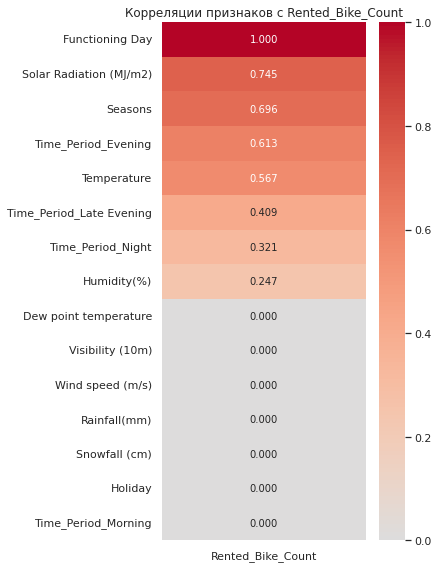

In [20]:
temp_df = df_train.copy()

correlation_matrix = temp_df.phik_matrix(interval_cols=numeric_columns)

orders_correlations = (
    correlation_matrix[['Rented_Bike_Count']]
    .drop(index='Rented_Bike_Count')
    .sort_values('Rented_Bike_Count', ascending=False)
)

plt.figure(figsize=(6, 8))
sns.heatmap(orders_correlations, annot=True,fmt='.3f',cmap='coolwarm',center=0)
plt.title('Корреляции признаков с Rented_Bike_Count')
plt.tight_layout()
plt.show()

удалим Functioning Day, тк он не несет никакой ифнормации. также удалим Time_Period_Morning, чтобы избежать мультиколлинеарности (тк в сумме поля с промежутком времени всегда равны 1)

In [21]:
df_train = df_train.drop(columns=['Functioning Day', 'Time_Period_Morning'])

### Разделение на трейн и тест тренировочной выборки

In [22]:
X = df_train.drop(columns=['Rented_Bike_Count'])
y = df_train['Rented_Bike_Count']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    
    random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

((5606, 13), (1402, 13))

### Построение пайпланов 

In [23]:
X_train.columns 

Index(['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
       'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (cm)', 'Seasons', 'Holiday', 'Time_Period_Evening',
       'Time_Period_Late Evening', 'Time_Period_Night'],
      dtype='object')

In [24]:
miss_val_columns = ['Snowfall (cm)', 'Rainfall(mm)',  'Visibility (10m)',
    'Humidity(%)', 'Solar Radiation (MJ/m2)', 'Wind speed (m/s)'
]

cat_columns = ['Seasons', 'Holiday']

In [25]:
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median', add_indicator=True), 
     [col for col in X_train.columns if col not in cat_columns]),

    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns)
])



knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=5))
])

tree_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=5, random_state=42))
])

In [26]:
def objective_knn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 2, 30),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_int("p", 1, 2)  
    }
    
    knn_pipe.set_params(model=KNeighborsRegressor(**params))
    
    score = cross_val_score(
        knn_pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    ).mean()
    
    return -score

In [27]:
def objective_tree(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"])
    }
    
    tree_pipe.set_params(model=DecisionTreeRegressor(random_state=42, **params))
    
    score = cross_val_score(
        tree_pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    ).mean()
    
    return -score

In [28]:
study_knn = optuna.create_study(direction="minimize")
study_knn.optimize(objective_knn, n_trials=30)

study_tree = optuna.create_study(direction="minimize")
study_tree.optimize(objective_tree, n_trials=30)

[I 2026-03-10 12:13:23,286] A new study created in memory with name: no-name-17876fe9-5230-446e-b376-89cf73d544d1
[I 2026-03-10 12:13:23,931] Trial 0 finished with value: 400.2079819103548 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 400.2079819103548.
[I 2026-03-10 12:13:24,701] Trial 1 finished with value: 387.2672091663847 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'p': 1}. Best is trial 1 with value: 387.2672091663847.
[I 2026-03-10 12:13:25,037] Trial 2 finished with value: 413.507080550502 and parameters: {'n_neighbors': 26, 'weights': 'uniform', 'p': 2}. Best is trial 1 with value: 387.2672091663847.
[I 2026-03-10 12:13:25,833] Trial 3 finished with value: 379.23778299004886 and parameters: {'n_neighbors': 24, 'weights': 'distance', 'p': 1}. Best is trial 3 with value: 379.23778299004886.
[I 2026-03-10 12:13:26,663] Trial 4 finished with value: 388.0292383157738 and parameters: {'n_neighbors': 15, 'weights': 'unifo

In [29]:
print("Лучшие параметры KNN:")
print(study_knn.best_params)
print("Лучший RMSE KNN:")
print(study_knn.best_value)

print()

print("Лучшие параметры дерева:")
print(study_tree.best_params)
print("Лучший RMSE дерева:")
print(study_tree.best_value)

Лучшие параметры KNN:
{'n_neighbors': 14, 'weights': 'distance', 'p': 1}
Лучший RMSE KNN:
376.91500282072116

Лучшие параметры дерева:
{'max_depth': 8, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': None}
Лучший RMSE дерева:
380.0857621908492


In [30]:
best_knn_pipe = knn_pipe.set_params(
    model=KNeighborsRegressor(**study_knn.best_params)
)

best_tree_pipe = tree_pipe.set_params(
    model=DecisionTreeRegressor(random_state=42, **study_tree.best_params)
)

In [31]:
best_knn_pipe.fit(X_train, y_train)
best_tree_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median'),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)',
                                                   'Time_Period_Evening',
                                                   'Time_Period_Late Evening',
                                                   'Time_Period_Night']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Seasons', 'Holiday'])])),
                ('model',
                 DecisionTreeRegressor(max_depth=8, min_samples_leaf=7,
                                       min_samples_split=13,
                                       random_state=42))])

In [32]:
import pandas as pd
from sklearn.model_selection import cross_validate

scoring = {
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

models = {
    'KNN': best_knn_pipe,
    'Decision Tree': best_tree_pipe
}

results = []

for name, model in models.items():
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )
    
    mse = -cv_results['test_mse']
    mae = -cv_results['test_mae']
    rmse = -cv_results['test_rmse']
    r2 = cv_results['test_r2']
    
    results.append({
        'Model': name,
        'MSE mean': mse.mean(),
        'MSE std': mse.std(),
        'RMSE mean': rmse.mean(),
        'RMSE std': rmse.std(),
        'MAE mean': mae.mean(),
        'MAE std': mae.std(),
        'R2 mean': r2.mean(),
        'R2 std': r2.std()
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('RMSE mean')
    .reset_index(drop=True)
)

results_df.round(3)

,Model,MSE mean,MSE std,RMSE mean,RMSE std,MAE mean,MAE std,R2 mean,R2 std
0,KNN,142205.087,8960.392,376.915,11.839,253.121,7.466,0.660,0.015
1,Decision Tree,144571.124,7774.533,380.086,10.293,247.721,6.586,0.655,0.010


значения бейзлайна:  
170177.993, 309.078, 0.593

In [33]:
perm = permutation_importance(
    best_knn_pipe,
    X_train,
    y_train,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df

,feature,importance_mean,importance_std
8,Seasons,0.578307,0.010445
10,Time_Period_Evening,0.285947,0.006118
1,Humidity(%),0.276081,0.004191
2,Wind speed (m/s),0.241413,0.002802
0,Temperature,0.240683,0.002747
3,Visibility (10m),0.231954,0.004026
4,Dew point temperature,0.224912,0.002287
5,Solar Radiation (MJ/m2),0.214138,0.003219
11,Time_Period_Late Evening,0.190179,0.006025
12,Time_Period_Night,0.146423,0.006738


По результатам кросс-валидации обе обученные модели заметно превосходят baseline. Базовая модель имеет RMSE около 309 и R^2 \approx 0.59, тогда как kNN и дерево решений снижают ошибку и лучше объясняют вариацию данных. Среди двух моделей немного лучше себя показывает kNN: у неё наименьший RMSE (≈ 376.8) и более высокий R^2 (≈ 0.66). Дерево решений даёт сопоставимые результаты (RMSE ≈ 381.8, R^2 ≈ 0.65), но немного уступает по точности, хотя при этом показывает чуть меньший разброс ошибок между фолдами.  
  
Анализ важности признаков показывает, что на прогноз сильнее всего влияют сезонность и время суток. Признак Seasons оказался самым важным, что логично: спрос на велосипеды сильно меняется в зависимости от времени года. Также значимыми являются вечерние часы, когда люди возвращаются с работы или учебы и чаще используют велосипеды. Среди погодных факторов наибольшее влияние оказывают влажность воздуха, скорость ветра и температура. В то же время такие признаки, как осадки (дождь и снег) и праздничные дни, оказывают меньшее влияние на прогноз по сравнению с основными погодными и временными факторами.

In [35]:
final_model = best_knn_pipe

X_test_final = df_test[X_train.columns].copy()
y_test_final = df_test['Rented_Bike_Count']

test_pred = final_model.predict(X_test_final)
    
mse = mean_squared_error(y_test_final, test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_final, test_pred)
r2 = r2_score(y_test_final, test_pred)
    
test_results = pd.DataFrame({
        'Model': ['Final KNN'],
        'Test MSE': [mse],
        'Test RMSE': [rmse],
        'Test MAE': [mae],
        'Test R2': [r2]
    })
    
display(test_results.round(3))

,Model,Test MSE,Test RMSE,Test MAE,Test R2
0,Final KNN,148238.436,385.017,260.729,0.638


По итогам проекта в качестве финальной модели была выбрана kNN-регрессия. На кросс-валидации она показала лучшие результаты среди рассмотренных моделей: немного обошла дерево решений по RMSE и R² и заметно превзошла baseline в виде линейной регрессии. Это значит, что для прогноза спроса на велосипеды важны не только линейные зависимости, но и более сложные сочетания погодных и временных факторов, которые kNN улавливает лучше. Для интерпретации модели был проведён анализ важности признаков: наибольший эффект дали сезон, вечернее время суток, а также влажность, скорость ветра, температура, видимость и точка росы. В бизнес-терминах это означает, что спрос в первую очередь определяется сочетанием сезона, времени дня и комфортности погоды: в хорошие погодные условия и в вечерние часы велосипедами пользуются заметно чаще, а ухудшение погоды снижает спрос. Для BikeSouth это означает, что модель можно использовать для более точного планирования количества велосипедов по времени суток и сезонам, а также для оперативной реакции на изменения погоды. Дальше качество прогноза можно улучшать за счёт новых признаков — например, дня недели, информации о специальных событиях, более точных погодных прогнозов и лаговых признаков спроса за предыдущие часы и дни.